## 🌸 Menstrual Health — Overall Health Score Prediction

## 1. 📦 Importing the libraries

In [70]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA

In [3]:
from sklearn.model_selection  import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing    import StandardScaler, OrdinalEncoder
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline

In [4]:
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm              import SVR

In [5]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error,root_mean_squared_error

In [6]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':      120,
    'font.family':     'DejaVu Sans',
    'axes.titlesize':  12,
    'axes.labelsize':  10
})

SEED = 42
np.random.seed(SEED)

## 2. 📊 Importing the Dataset

In [7]:
df=pd.read_csv(r"C:\Users\LAYA\Desktop\CP2\Period_Log.csv")

## 3. 🧹 Data Wrangling & Cleaning

In [8]:
df.head(3)

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,13-02-2024,33,NaN,Luteal,Heavy,9,Yes,6,...,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,17-03-2024,33,33.0,Follicular,Light,2,No,8,...,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
2,U00001,3,19-04-2024,34,33.0,Follicular,Heavy,8,No,5,...,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1


In [9]:
df.tail(3)

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
17973,U02000,8,28-08-2024,30,27.0,Menstrual,Moderate,6,No,5,...,4.5,6,7,4.6,51.9,1.26,Negative,7.6,0.946,0
17974,U02000,9,27-09-2024,29,30.0,Luteal,Light,3,No,8,...,4.9,6,8,3.0,85.3,8.99,Positive,8.8,0.946,1
17975,U02000,10,26-10-2024,27,29.0,Follicular,Moderate,4,Yes,8,...,4.6,7,9,3.7,109.1,2.17,Negative,8.5,0.946,1


In [10]:
df.shape

(17976, 21)

In [11]:
df.ndim

2

In [12]:
df.ndim

2

In [13]:
df.dtypes

user_id                    object
cycle_number                int64
start_date                 object
cycle_length_days           int64
prev_cycle_length         float64
cycle_phase                object
flow_level                 object
pain_level                  int64
pms_symptoms               object
mood_score                  int64
stress_score_cycle        float64
sleep_hours_cycle         float64
energy_level                int64
concentration_score         int64
work_hours_lost           float64
estrogen_pgml             float64
progesterone_ngml         float64
ovulation_result           object
overall_health_score      float64
log_consistency_score     float64
prepared_before_period      int64
dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17976 entries, 0 to 17975
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 17976 non-null  object 
 1   cycle_number            17976 non-null  int64  
 2   start_date              17976 non-null  object 
 3   cycle_length_days       17976 non-null  int64  
 4   prev_cycle_length       15976 non-null  float64
 5   cycle_phase             17976 non-null  object 
 6   flow_level              17976 non-null  object 
 7   pain_level              17976 non-null  int64  
 8   pms_symptoms            17976 non-null  object 
 9   mood_score              17976 non-null  int64  
 10  stress_score_cycle      17976 non-null  float64
 11  sleep_hours_cycle       17976 non-null  float64
 12  energy_level            17976 non-null  int64  
 13  concentration_score     17976 non-null  int64  
 14  work_hours_lost         17976 non-null

In [15]:
df.describe()

,cycle_number,cycle_length_days,prev_cycle_length,pain_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period
count,17976.000000,17976.000000,15976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000,17976.000000
mean,5.214842,27.816756,27.826865,4.854473,7.084947,5.749260,6.960253,6.832165,7.352025,3.394443,96.429840,5.336521,8.548665,0.935288,0.567701
std,2.931241,2.400329,2.399832,2.230292,1.506431,1.771953,1.315146,1.687533,1.435035,1.495181,27.928743,3.791151,1.106405,0.020129,0.495409
min,1.000000,22.000000,22.000000,1.000000,1.000000,1.000000,4.500000,1.000000,2.000000,0.000000,10.000000,0.100000,4.400000,0.860000,0.000000
25%,3.000000,26.000000,26.000000,3.000000,6.000000,4.500000,6.000000,6.000000,6.000000,2.300000,76.300000,2.230000,7.800000,0.921000,0.000000
50%,5.000000,28.000000,28.000000,5.000000,7.000000,5.800000,7.000000,7.000000,7.000000,3.400000,94.300000,3.830000,8.600000,0.936000,1.000000
75%,7.000000,29.000000,29.000000,6.000000,8.000000,7.000000,7.900000,8.000000,8.000000,4.400000,115.100000,8.370000,9.500000,0.950000,1.000000
max,12.000000,44.000000,44.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,8.800000,206.500000,20.250000,10.000000,0.985000,1.000000


In [16]:
df.isnull().sum()

user_id                      0
cycle_number                 0
start_date                   0
cycle_length_days            0
prev_cycle_length         2000
cycle_phase                  0
flow_level                   0
pain_level                   0
pms_symptoms                 0
mood_score                   0
stress_score_cycle           0
sleep_hours_cycle            0
energy_level                 0
concentration_score          0
work_hours_lost              0
estrogen_pgml                0
progesterone_ngml            0
ovulation_result             0
overall_health_score         0
log_consistency_score        0
prepared_before_period       0
dtype: int64

In [17]:
df.fillna(df["prev_cycle_length"].mean(),inplace=True)

In [18]:
df.isnull().sum()

user_id                   0
cycle_number              0
start_date                0
cycle_length_days         0
prev_cycle_length         0
cycle_phase               0
flow_level                0
pain_level                0
pms_symptoms              0
mood_score                0
stress_score_cycle        0
sleep_hours_cycle         0
energy_level              0
concentration_score       0
work_hours_lost           0
estrogen_pgml             0
progesterone_ngml         0
ovulation_result          0
overall_health_score      0
log_consistency_score     0
prepared_before_period    0
dtype: int64

In [19]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17971    False
17972    False
17973    False
17974    False
17975    False
Length: 17976, dtype: bool

In [20]:
def iqr_summary(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        rows.append({'Feature': col, 'Lower Fence': round(lo,2),
                     'Upper Fence': round(hi,2), 'Outliers': n_out})
    return pd.DataFrame(rows).set_index('Feature')

check_cols = ['estrogen_pgml','progesterone_ngml','pain_level',
              'sleep_hours_cycle','overall_health_score']
print('=== IQR Outlier Summary ===')
display(iqr_summary(df, check_cols))

=== IQR Outlier Summary ===


,Lower Fence,Upper Fence,Outliers
Feature,,,
estrogen_pgml,18.10,173.30,94
progesterone_ngml,-6.98,17.58,10
pain_level,-1.50,10.50,0
sleep_hours_cycle,3.15,10.75,0
overall_health_score,5.25,12.05,16


## 4. 🔍 Exploratory Data Analysis & Visualisation

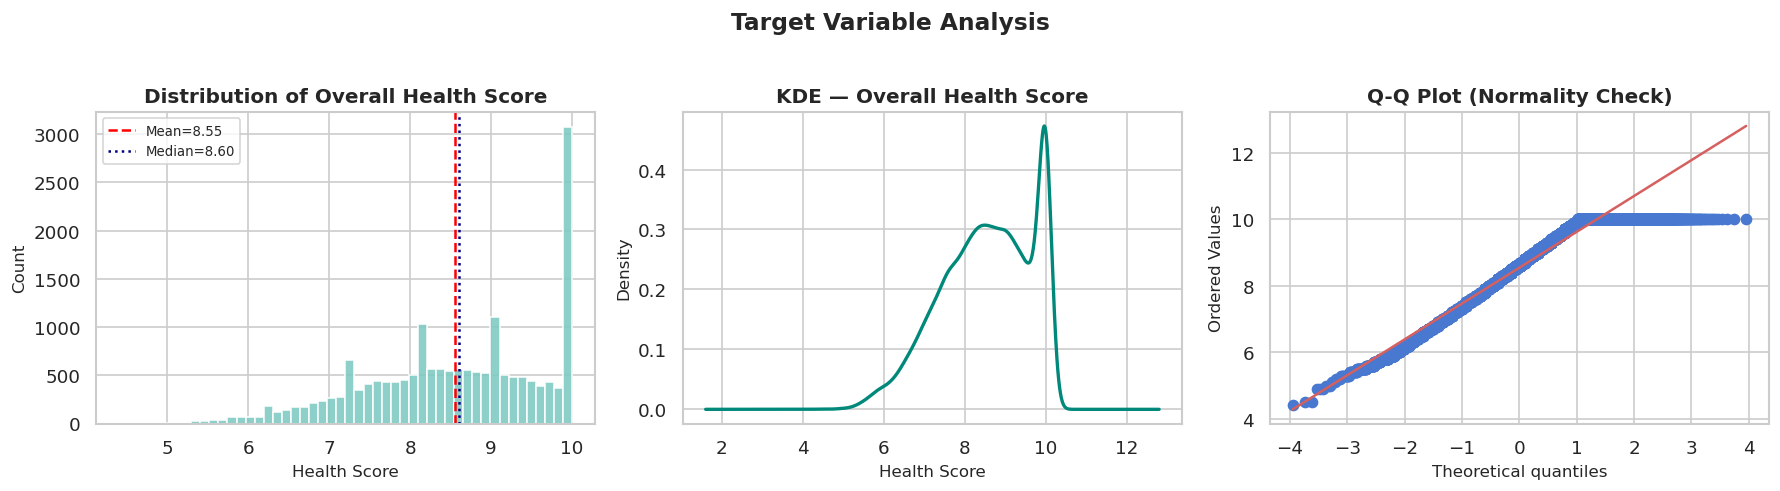

Mean    : 8.5487
Median  : 8.6000
Std Dev : 1.1064
Skew    : -0.4485
Kurtosis: -0.5541
Range   : [4.4, 10.0]


In [21]:
TARGET = 'overall_health_score'
target = df[TARGET]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(target, bins=50, color='#80CBC4', edgecolor='white', alpha=0.9)
axes[0].axvline(target.mean(),   color='red',   ls='--', lw=1.5, label=f'Mean={target.mean():.2f}')
axes[0].axvline(target.median(), color='navy',  ls=':',  lw=1.5, label=f'Median={target.median():.2f}')
axes[0].legend(fontsize=8)
axes[0].set_title('Distribution of Overall Health Score', fontweight='bold')
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('Count')

target.plot.kde(ax=axes[1], color='#00897B', lw=2)
axes[1].set_title('KDE — Overall Health Score', fontweight='bold')
axes[1].set_xlabel('Health Score')

stats.probplot(target, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"Mean    : {target.mean():.4f}")
print(f"Median  : {target.median():.4f}")
print(f"Std Dev : {target.std():.4f}")
print(f"Skew    : {target.skew():.4f}")
print(f"Kurtosis: {target.kurtosis():.4f}")
print(f"Range   : [{target.min():.1f}, {target.max():.1f}]")

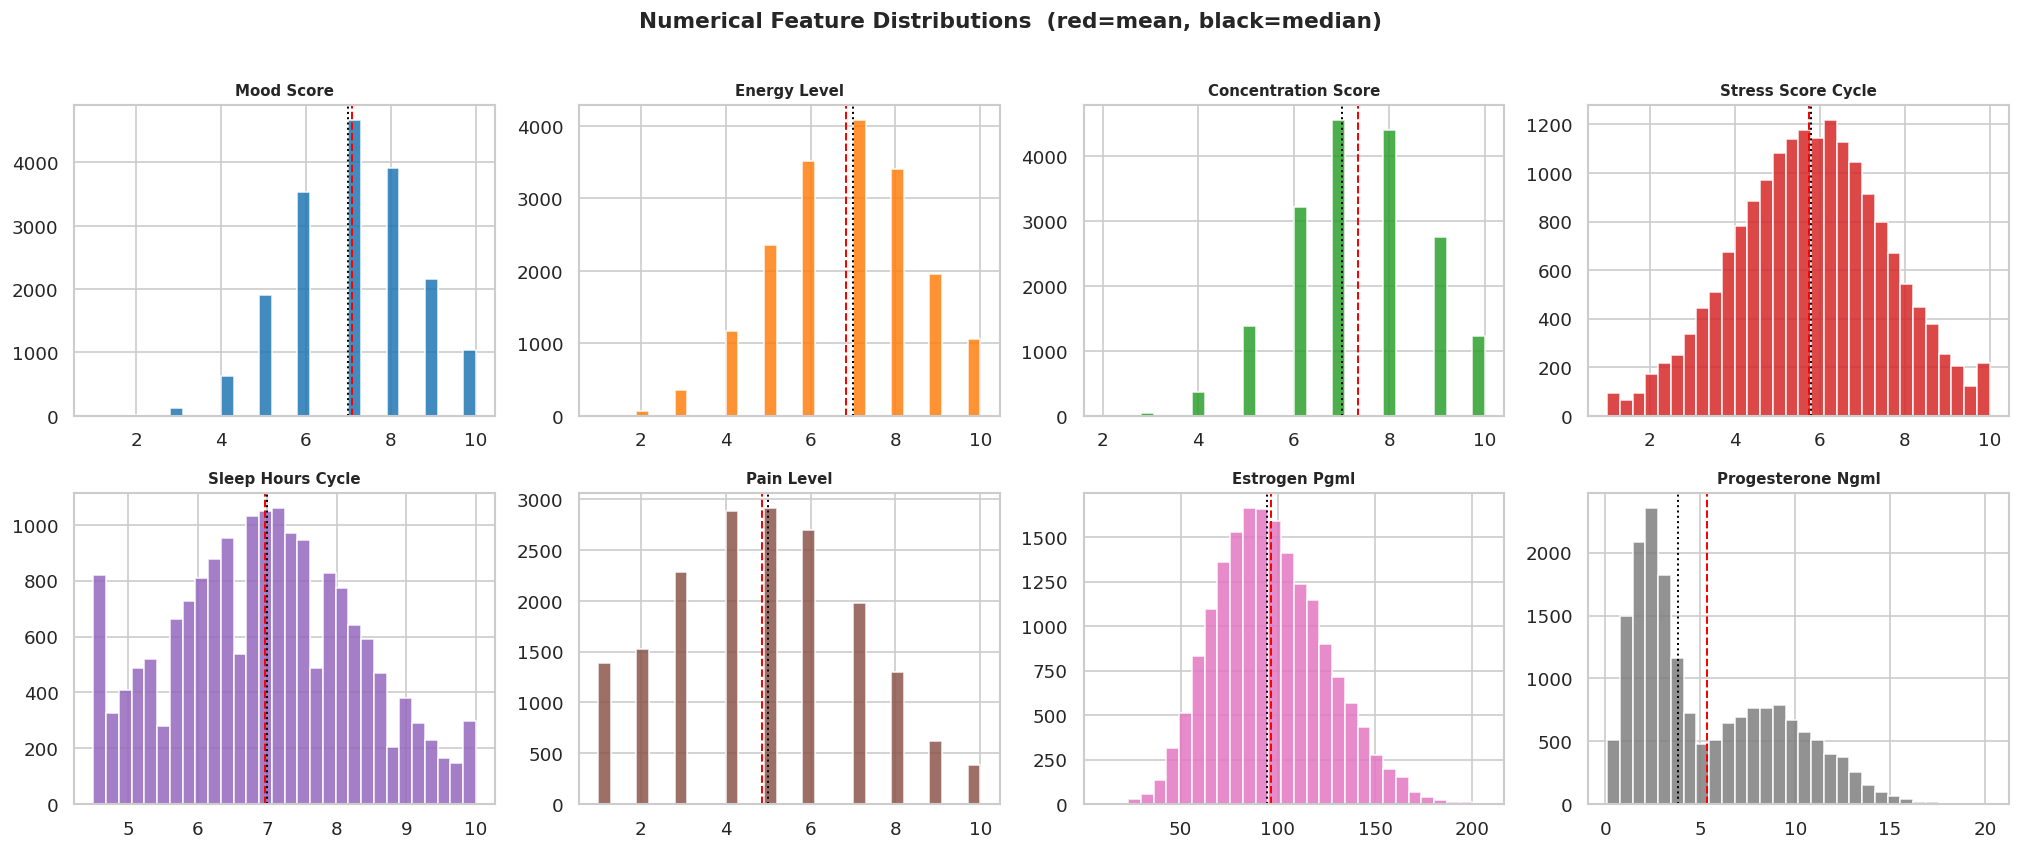

In [22]:
num_feats = [
    'mood_score','energy_level','concentration_score',
    'stress_score_cycle','sleep_hours_cycle','pain_level',
    'estrogen_pgml','progesterone_ngml'
]

cmap = plt.cm.get_cmap('tab10')
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for i, col in enumerate(num_feats):
    ax = axes[i//4, i%4]
    ax.hist(df[col], bins=30, color=cmap(i), edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',  ls='--', lw=1.2)
    ax.axvline(df[col].median(), color='black',ls=':',  lw=1.2)
    ax.set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')

plt.suptitle('Numerical Feature Distributions  (red=mean, black=median)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

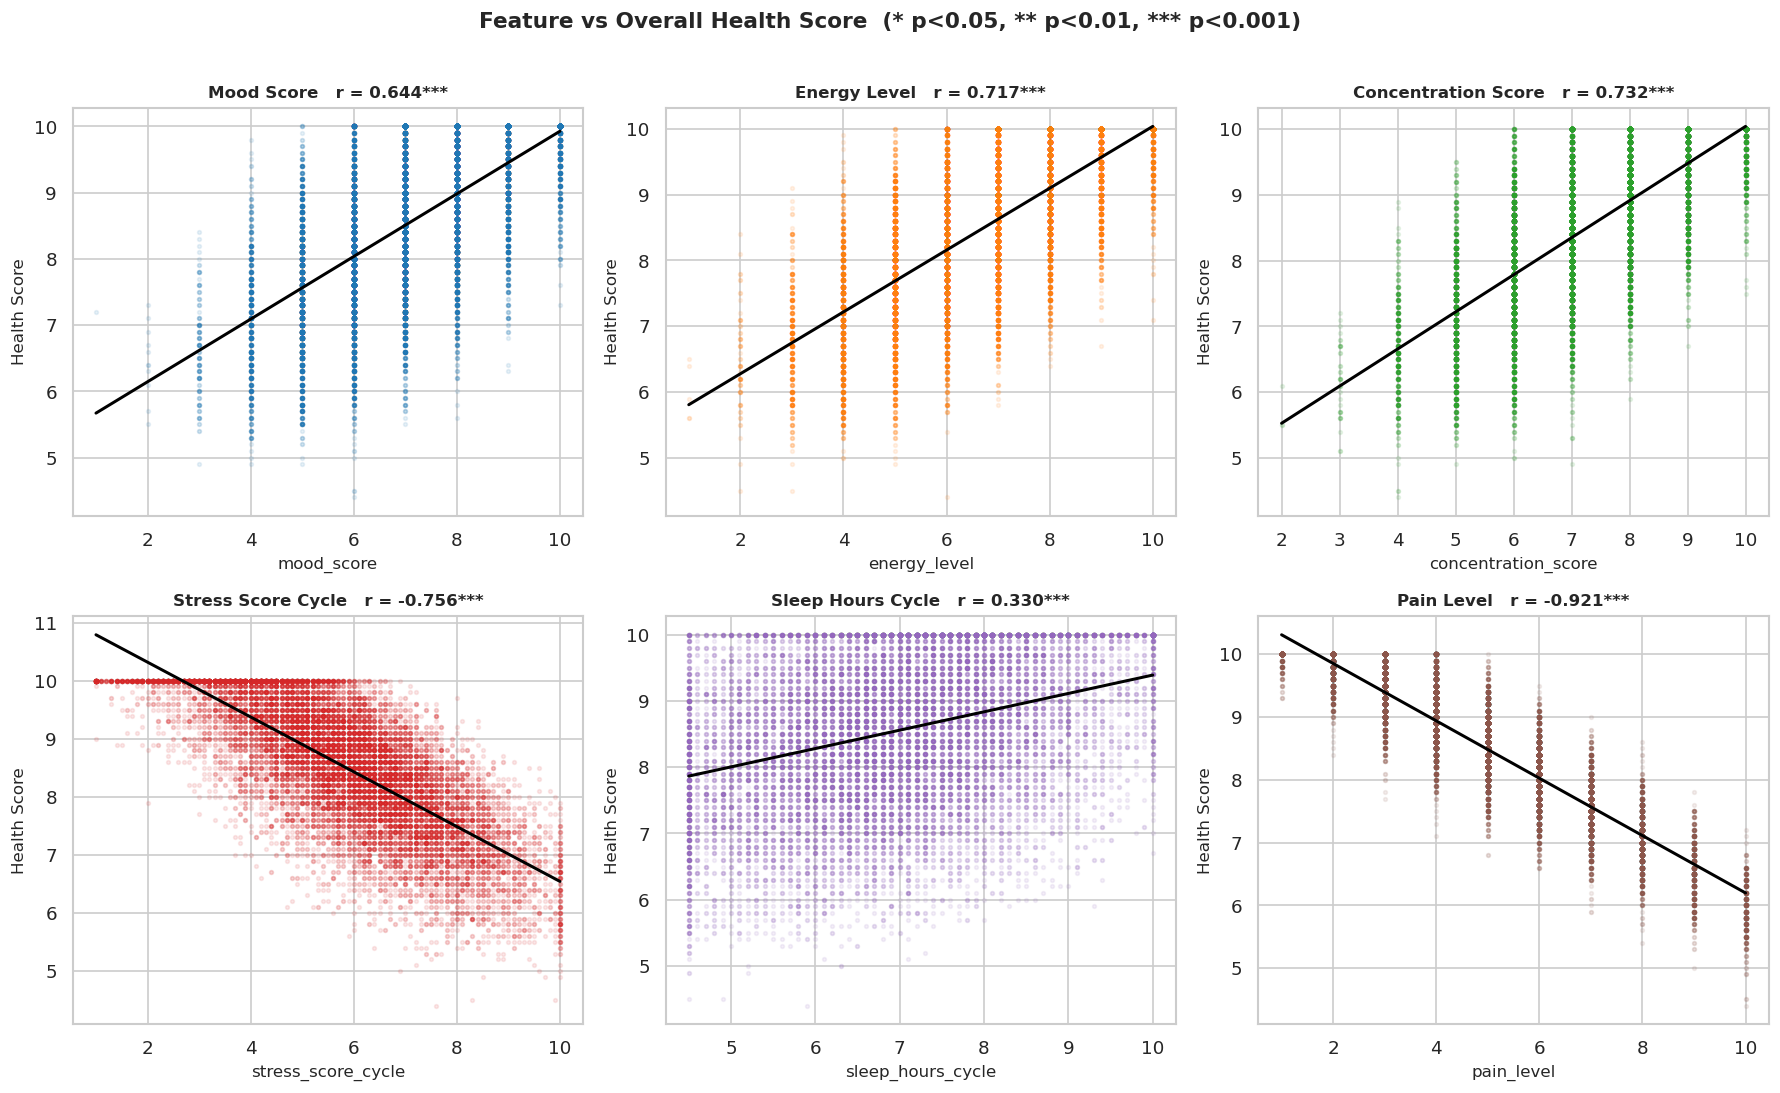

In [23]:
scatter_feats = [
    'mood_score','energy_level','concentration_score',
    'stress_score_cycle','sleep_hours_cycle','pain_level'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, col in enumerate(scatter_feats):
    ax = axes[i//3, i%3]
    ax.scatter(df[col], df[TARGET], alpha=0.1, s=5, color=cmap(i))
    m, b  = np.polyfit(df[col], df[TARGET], 1)
    xline = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xline, m*xline + b, 'black', lw=1.8)
    r, p  = stats.pearsonr(df[col], df[TARGET])
    sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax.set_title(f'{col.replace("_"," ").title()}   r = {r:.3f}{sig}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Health Score')

plt.suptitle('Feature vs Overall Health Score  (* p<0.05, ** p<0.01, *** p<0.001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

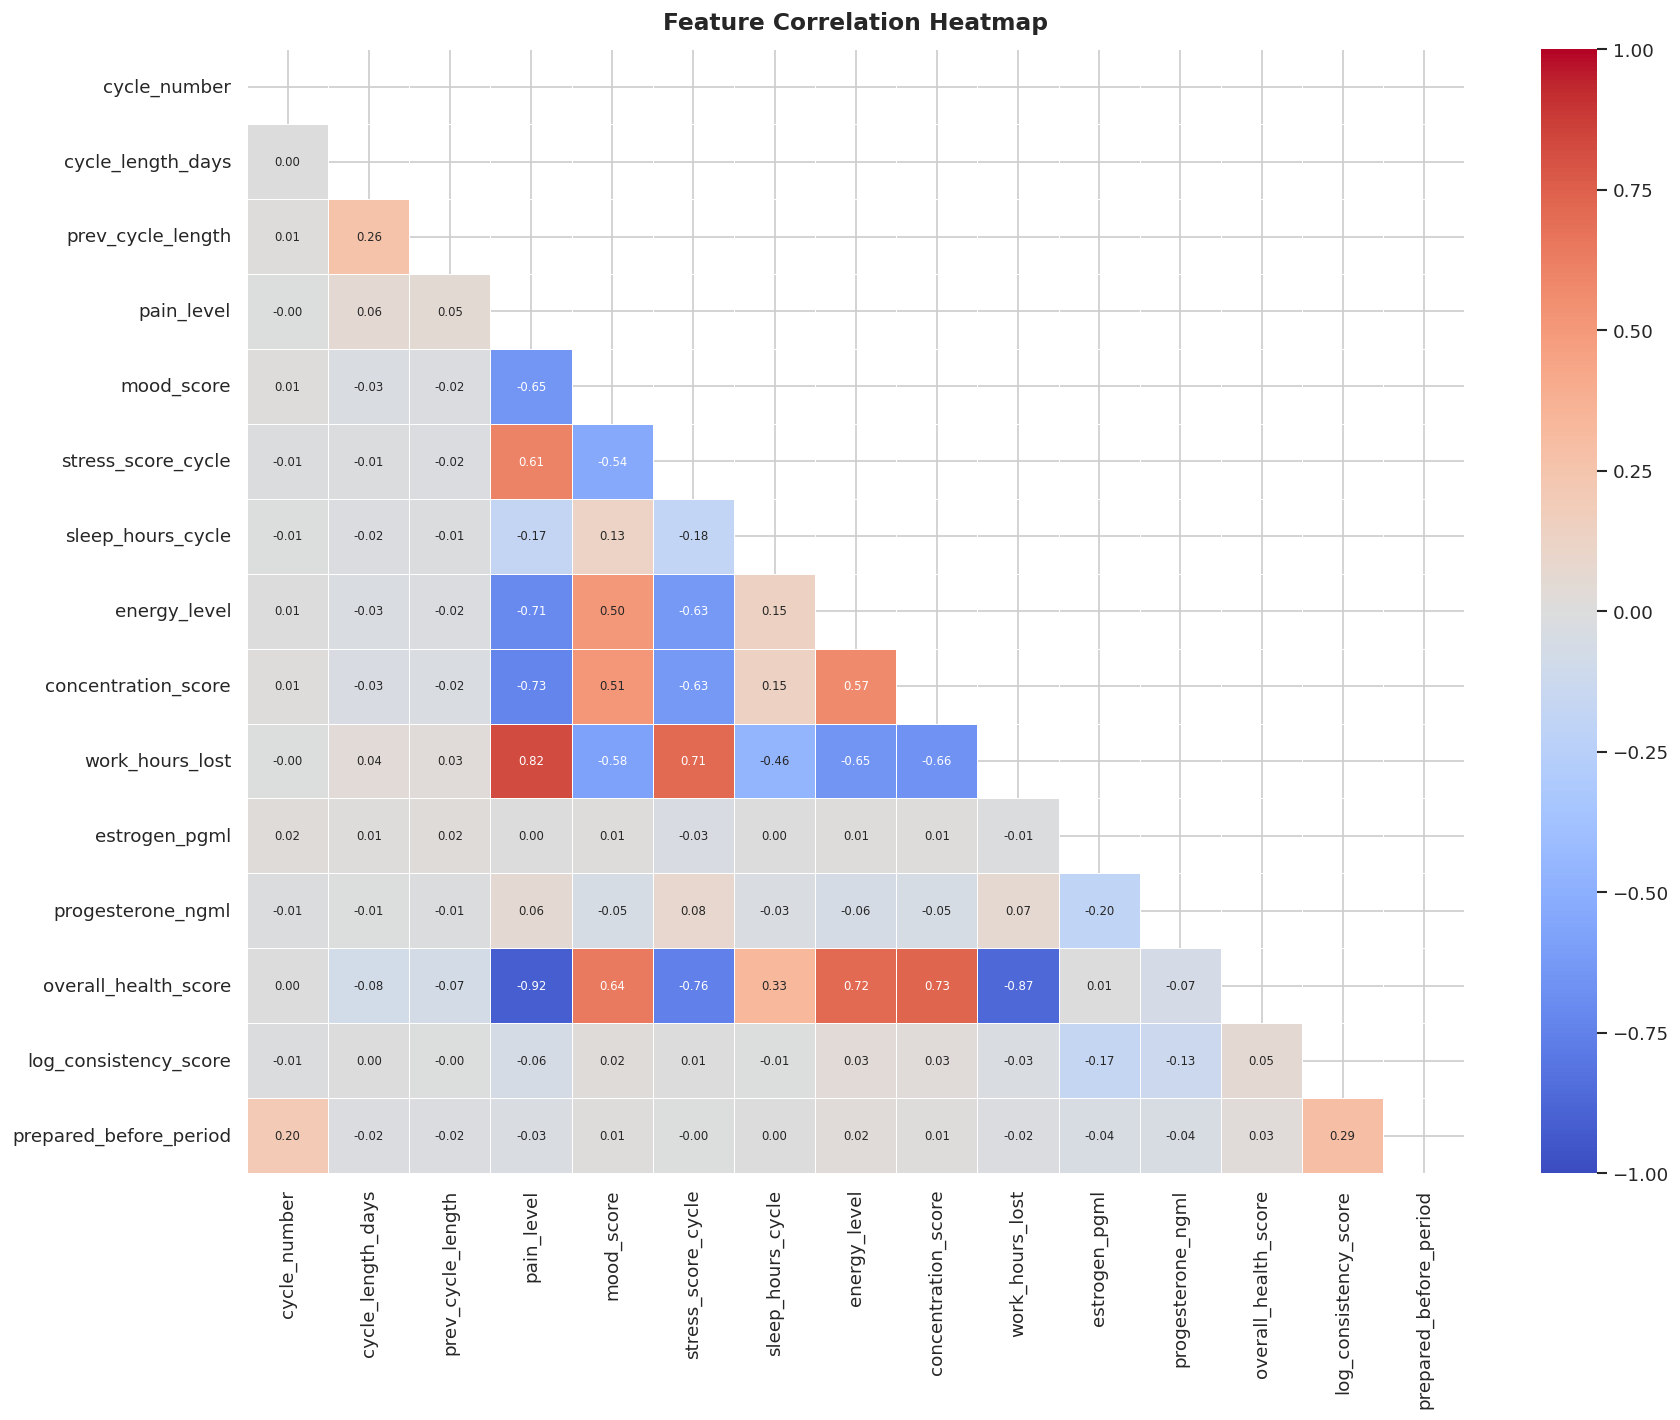


Top correlations with overall_health_score:
pain_level               -0.921
work_hours_lost          -0.870
stress_score_cycle       -0.756
concentration_score       0.732
energy_level              0.717
mood_score                0.644
sleep_hours_cycle         0.330
cycle_length_days        -0.083
prev_cycle_length        -0.072
progesterone_ngml        -0.069
log_consistency_score     0.055
prepared_before_period    0.028
estrogen_pgml             0.006
cycle_number              0.002


In [24]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr     = df[num_cols].corr()

fig, ax  = plt.subplots(figsize=(15, 12))
mask     = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size':7},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

# Print top correlations with target
print('\nTop correlations with overall_health_score:')
top_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(top_corr.round(3).to_string())

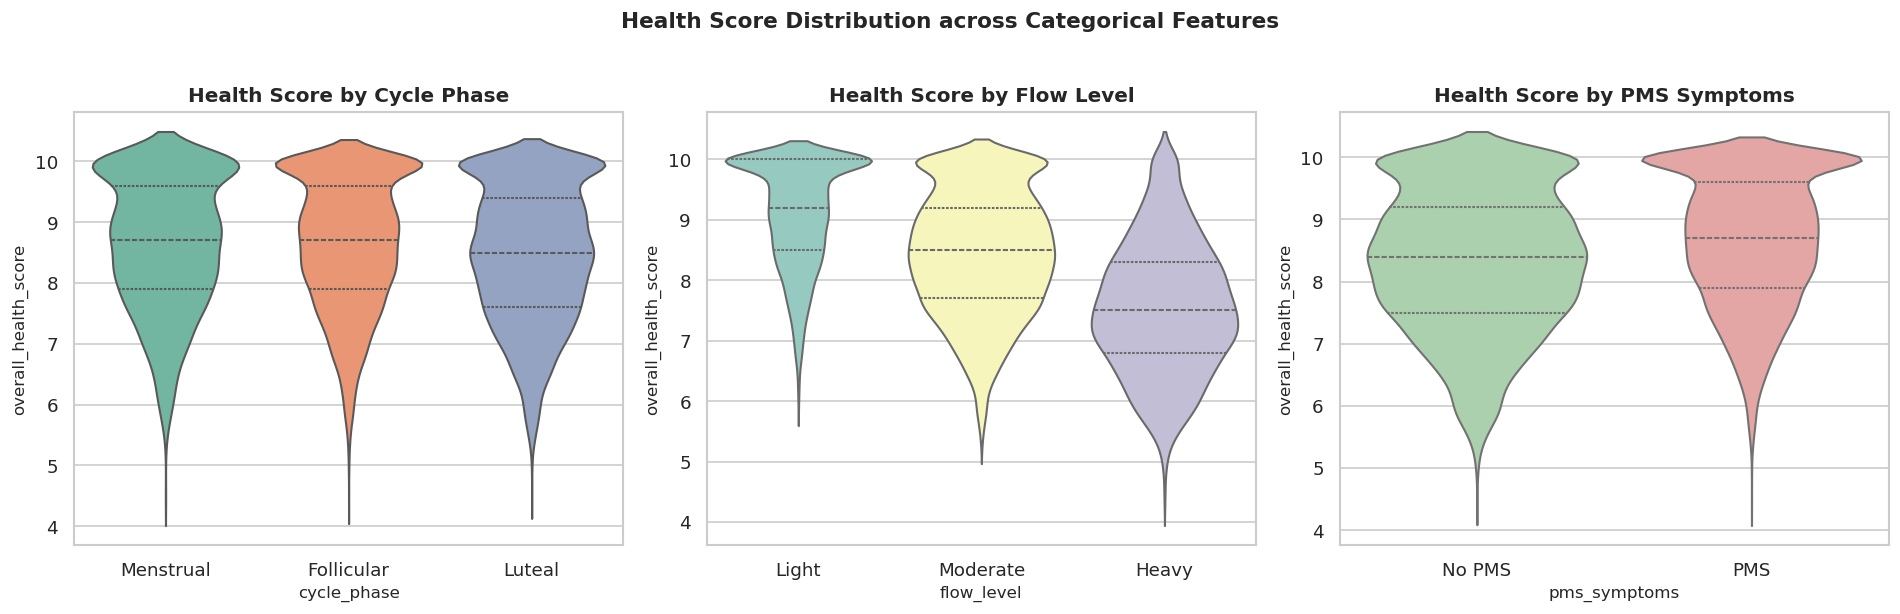

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# cycle_phase
phase_order = ['Menstrual','Follicular','Luteal']
sns.violinplot(data=df, x='cycle_phase', y=TARGET, order=phase_order,
               ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('Health Score by Cycle Phase', fontweight='bold')

# flow_level
flow_order = ['Light','Moderate','Heavy']
sns.violinplot(data=df, x='flow_level', y=TARGET, order=flow_order,
               ax=axes[1], palette='Set3', inner='quartile')
axes[1].set_title('Health Score by Flow Level', fontweight='bold')

# pms_symptoms (already encoded)
sns.violinplot(data=df, x='pms_symptoms', y=TARGET,
               ax=axes[2], palette=['#A5D6A7','#EF9A9A'], inner='quartile')
axes[2].set_xticklabels(['No PMS','PMS'])
axes[2].set_title('Health Score by PMS Symptoms', fontweight='bold')

plt.suptitle('Health Score Distribution across Categorical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [26]:
df_temp = df.copy()

# Ensure datetime
df_temp['start_date'] = pd.to_datetime(df_temp['start_date'], errors='coerce')

# Create monthly feature
df_temp['ym'] = df_temp['start_date'].dt.to_period('M')

# Aggregate
monthly = (
    df_temp.groupby('ym')['overall_health_score']
    .agg(['mean','std','count'])
    .reset_index()
)

monthly['ym_str'] = monthly['ym'].astype(str)

print(monthly.head(10))

        ym      mean       std  count   ym_str
0  2024-01  8.604768  1.075746    776  2024-01
1  2024-02  8.504465  1.118662   1411  2024-02
2  2024-03  8.529396  1.115665   2235  2024-03
3  2024-04  8.563745  1.105213   2179  2024-04
4  2024-05  8.560143  1.109765   2243  2024-05
5  2024-06  8.540419  1.102287   2098  2024-06
6  2024-07  8.562974  1.106688   2004  2024-07
7  2024-08  8.560376  1.097041   1701  2024-08
8  2024-09  8.558976  1.110496   1270  2024-09
9  2024-10  8.554306  1.094208    987  2024-10


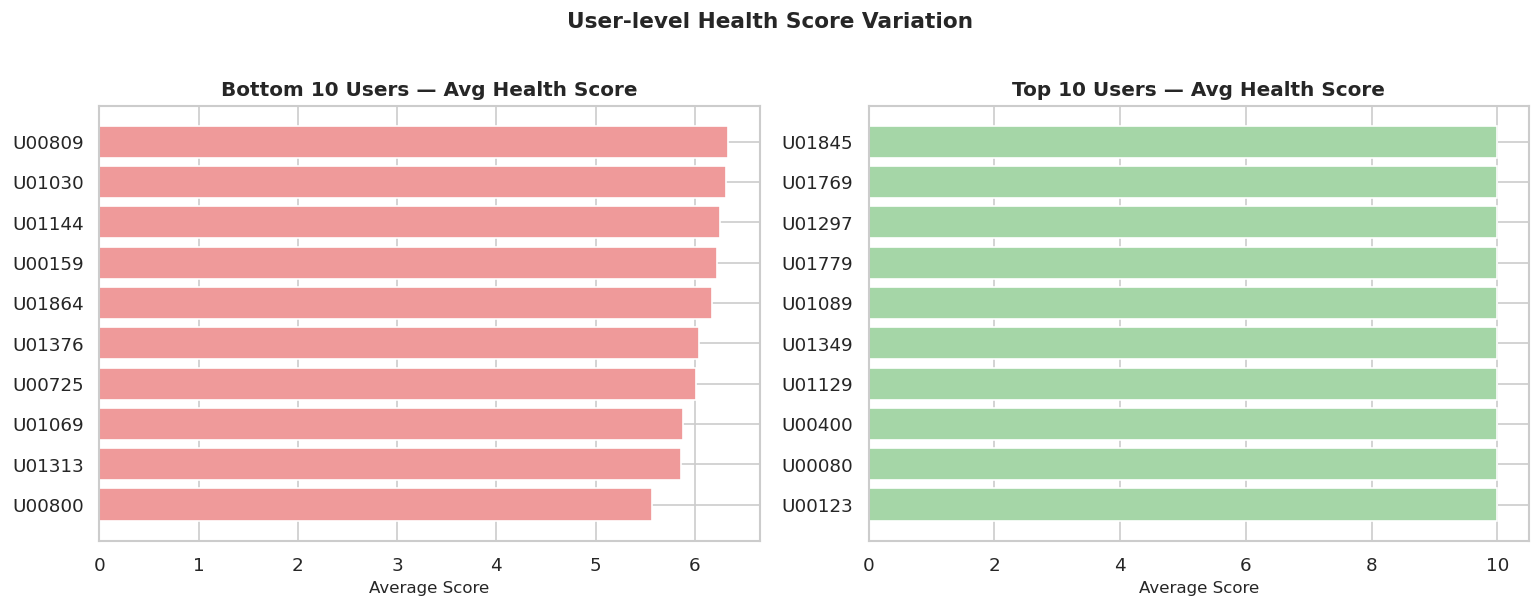

In [27]:
user_health = (df.groupby('user_id')[TARGET]
               .agg(['mean','count'])
               .query('count >= 6')
               .sort_values('mean'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bottom 10
axes[0].barh(user_health.head(10).index,
             user_health.head(10)['mean'], color='#EF9A9A')
axes[0].set_title('Bottom 10 Users — Avg Health Score', fontweight='bold')
axes[0].set_xlabel('Average Score')

# Top 10
axes[1].barh(user_health.tail(10).index,
             user_health.tail(10)['mean'], color='#A5D6A7')
axes[1].set_title('Top 10 Users — Avg Health Score', fontweight='bold')
axes[1].set_xlabel('Average Score')

plt.suptitle('User-level Health Score Variation', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

Top 5 features by |correlation| with target: ['pain_level', 'work_hours_lost', 'stress_score_cycle', 'concentration_score', 'energy_level']


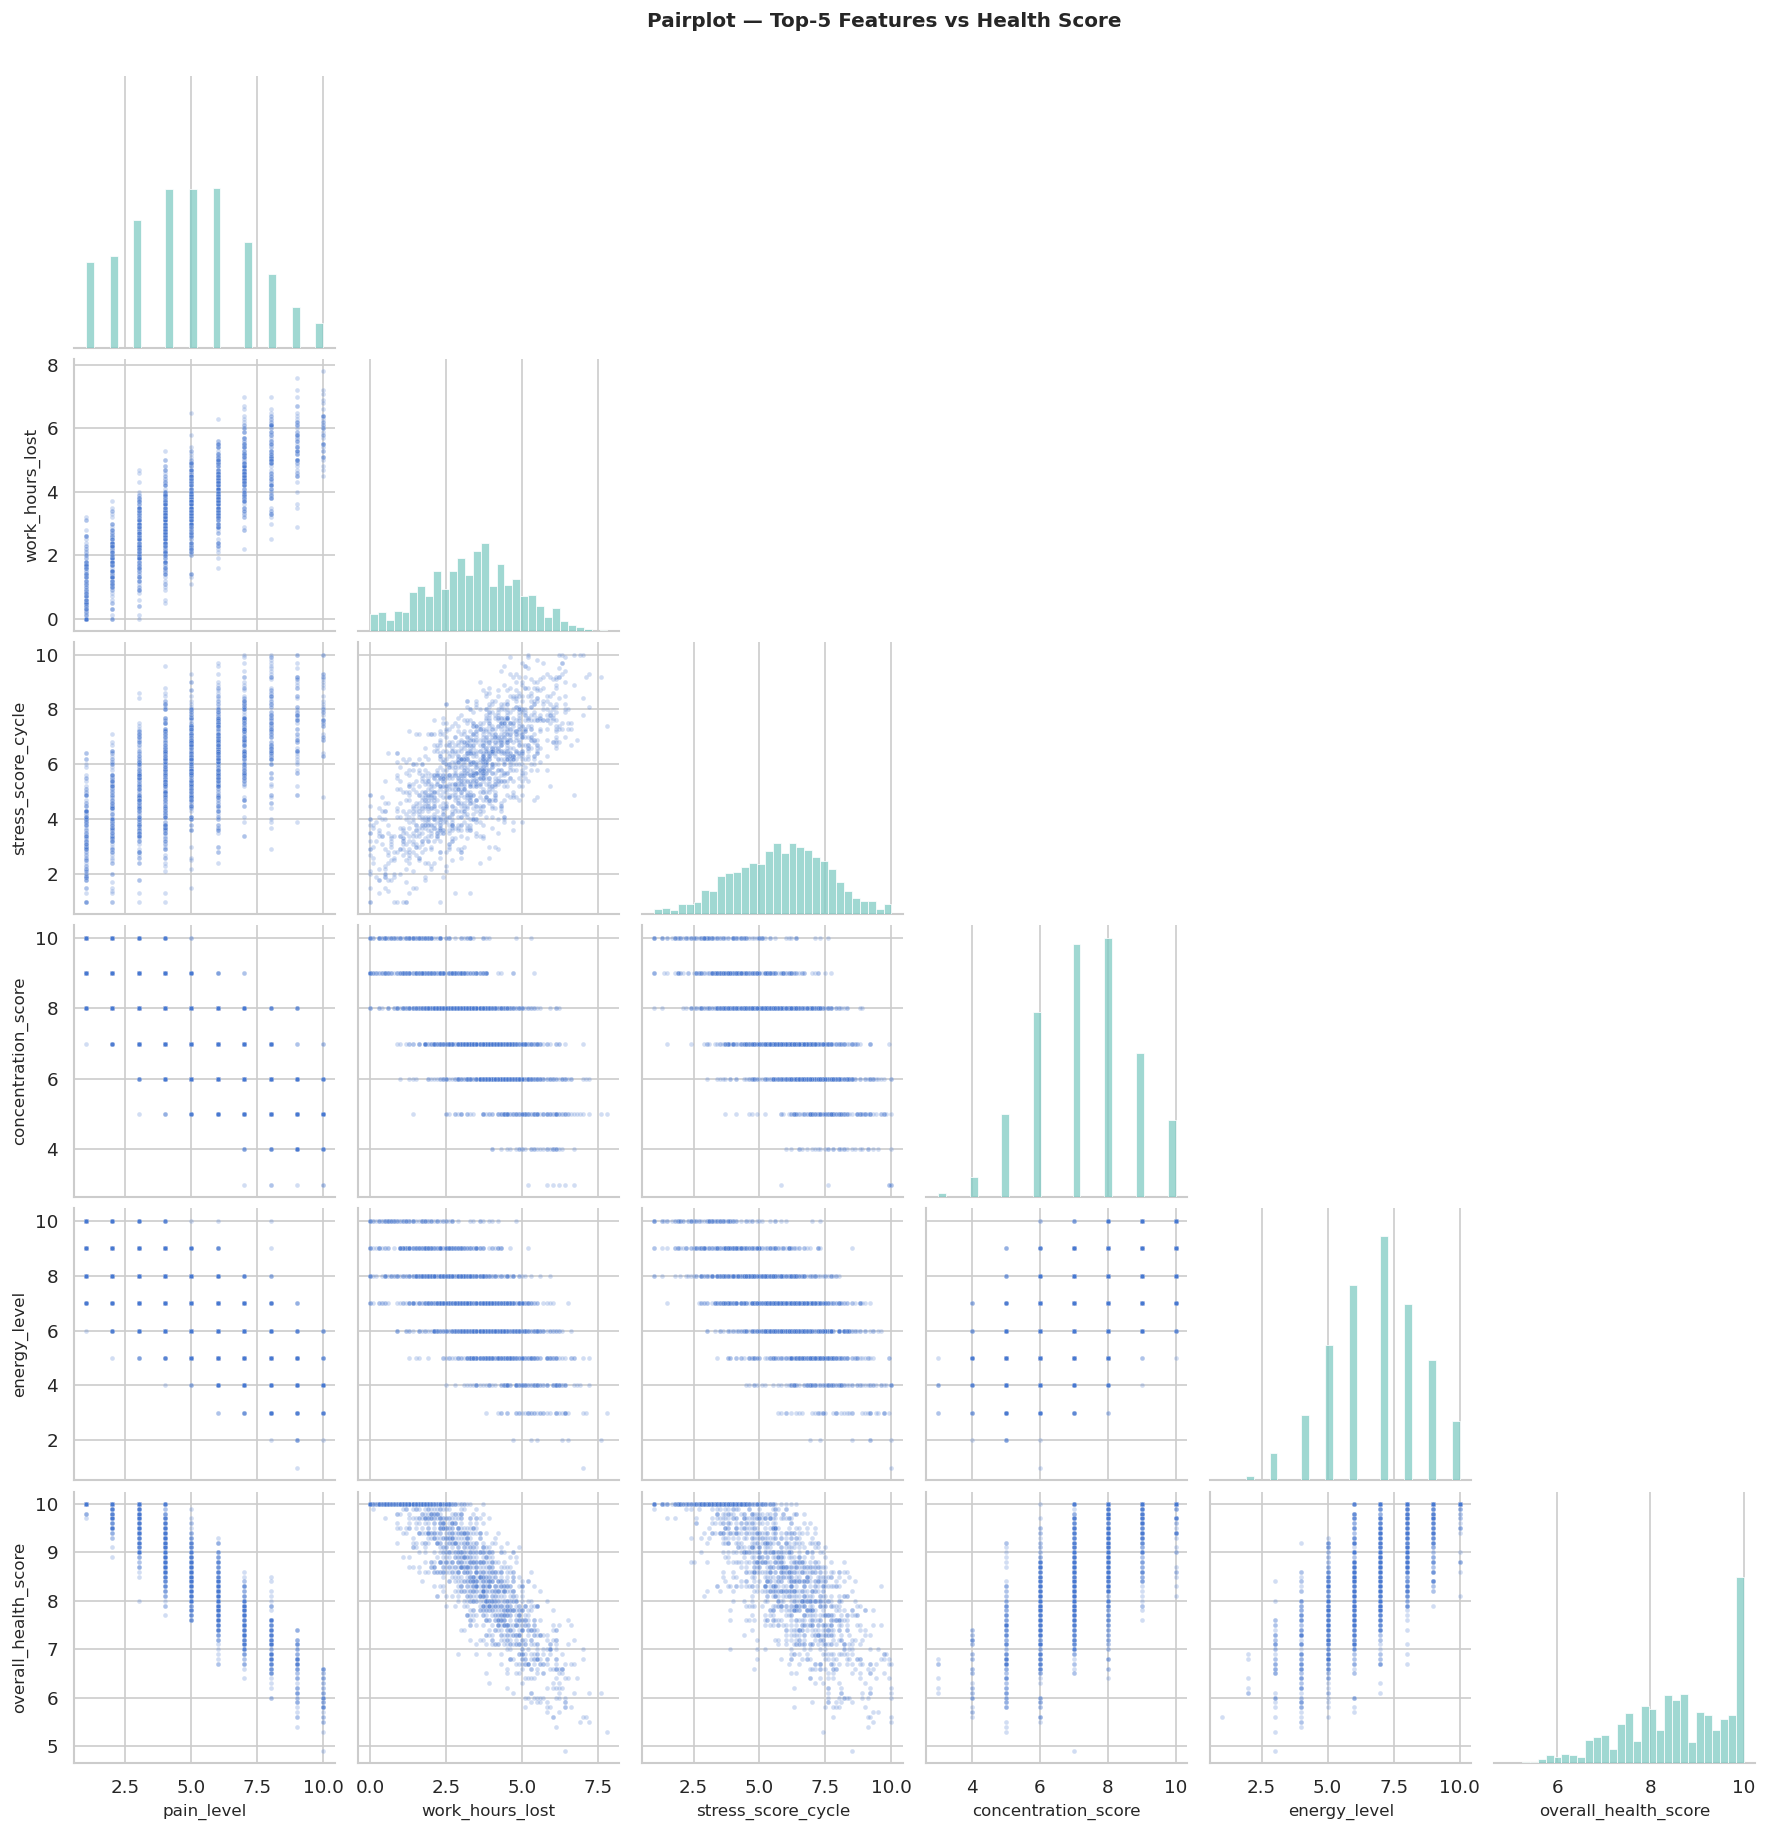

In [28]:
top5 = top_corr.abs().nlargest(5).index.tolist()
print('Top 5 features by |correlation| with target:', top5)

# Sample to keep pairplot fast
sample = df[top5 + [TARGET]].sample(1500, random_state=SEED)
g = sns.pairplot(sample, corner=True,
                 plot_kws={'alpha':0.25, 's':8},
                 diag_kws={'color':'#80CBC4', 'bins':30})
g.figure.suptitle('Pairplot — Top-5 Features vs Health Score',
                   y=1.02, fontsize=12, fontweight='bold')
plt.show()

## 5. ⚙️ Feature Engineering & Data Transformation

In [29]:
def cycle_regularity(df):
    df = df.copy()
    
    df['cycle_length_diff'] = abs(df['cycle_length_days'] - df['prev_cycle_length'])
    df['is_regular_cycle']  = (df['cycle_length_diff'] <= 3).astype(int)
    
    return df

In [30]:
df = cycle_regularity(df)
print(df[['cycle_length_days','prev_cycle_length',
          'cycle_length_diff','is_regular_cycle']].head())

   cycle_length_days  prev_cycle_length  cycle_length_diff  is_regular_cycle
0                 33          27.826865           5.173135                 0
1                 33          33.000000           0.000000                 1
2                 34          33.000000           1.000000                 1
3                 31          34.000000           3.000000                 1
4                 31          31.000000           0.000000                 1


In [31]:
print(df[['cycle_length_diff','is_regular_cycle']].describe())

       cycle_length_diff  is_regular_cycle
count       17976.000000      17976.000000
mean            2.185012          0.794059
std             1.808965          0.404399
min             0.000000          0.000000
25%             1.000000          1.000000
50%             2.000000          1.000000
75%             3.000000          1.000000
max            14.000000          1.000000


In [32]:
def hormone_features(df):
    df = df.copy()
    
    df['hormone_ratio'] = df['estrogen_pgml'] / (df['progesterone_ngml'] + 1e-5)
    df['hormone_product'] = (df['estrogen_pgml'] * df['progesterone_ngml']) / 1000
    
    return df

In [33]:
df = hormone_features(df)
print(df[['estrogen_pgml','progesterone_ngml',
          'hormone_ratio','hormone_product']].head())

   estrogen_pgml  progesterone_ngml  hormone_ratio  hormone_product
0           84.7               4.14      20.458888         0.350658
1          126.1               2.79      45.196971         0.351819
2          131.1               1.70      77.117193         0.222870
3           82.0               8.50       9.647047         0.697000
4           55.5               6.30       8.809510         0.349650


In [34]:
print(df[['hormone_ratio','hormone_product']].describe())

       hormone_ratio  hormone_product
count   17976.000000     17976.000000
mean       36.342201         0.493835
std        58.067220         0.351173
min         0.750187         0.002810
25%        10.169602         0.226948
50%        27.011536         0.406095
75%        46.867812         0.693325
max      2064.793521         2.164800


In [35]:
def sleep_quality_bin(df):
    df = df.copy()
    
    df['sleep_quality'] = pd.cut(
        df['sleep_hours_cycle'],
        bins=[0, 5.5, 7.0, 8.5, 99],
        labels=[0, 1, 2, 3]
    ).astype(float)
    
    return df

In [36]:
df = sleep_quality_bin(df)
print(df[['sleep_hours_cycle','sleep_quality']].head())

   sleep_hours_cycle  sleep_quality
0                5.3            0.0
1                4.6            0.0
2                5.1            0.0
3                6.7            1.0
4                5.8            1.0


In [37]:
print(df['sleep_quality'].value_counts())

sleep_quality
1.0    6655
2.0    6299
0.0    2842
3.0    2180
Name: count, dtype: int64


In [38]:
def wellbeing_index(df):
    df = df.copy()
    
    df['wellbeing_index'] = (
        df['mood_score'] +
        df['energy_level'] +
        df['concentration_score']
    ) / 3.0
    
    return df

In [39]:
df = wellbeing_index(df)
print(df[['mood_score','energy_level','concentration_score',
          'wellbeing_index']].head())

   mood_score  energy_level  concentration_score  wellbeing_index
0           6             6                    7         6.333333
1           8             7                    8         7.666667
2           5             5                    5         5.000000
3           8             8                    8         8.000000
4           9             9                    8         8.666667


In [40]:
print(df['wellbeing_index'].describe())

count    17976.000000
mean         7.089712
std          1.279149
min          2.666667
25%          6.333333
50%          7.000000
75%          8.000000
max         10.000000
Name: wellbeing_index, dtype: float64


In [41]:
def stress_sleep_interaction(df):
    df = df.copy()
    
    df['stress_sleep_ratio'] = df['stress_score_cycle'] / (df['sleep_hours_cycle'] + 1e-5)
    
    return df

In [42]:
df = stress_sleep_interaction(df)
print(df[['stress_score_cycle','sleep_hours_cycle',
          'stress_sleep_ratio']].head())

   stress_score_cycle  sleep_hours_cycle  stress_sleep_ratio
0                 5.4                5.3            1.018866
1                 3.7                4.6            0.804346
2                 5.7                5.1            1.117645
3                 5.2                6.7            0.776118
4                 3.7                5.8            0.637930


In [43]:
print(df['stress_sleep_ratio'].describe())

count    17976.000000
mean         0.867383
std          0.347375
min          0.100000
25%          0.620689
50%          0.828570
75%          1.073528
max          2.222217
Name: stress_sleep_ratio, dtype: float64


In [44]:
def calendar_features(df):
    df = df.copy()
    
    df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
    
    df['cycle_month']   = df['start_date'].dt.month
    df['cycle_quarter'] = df['start_date'].dt.quarter
    df['day_of_week']   = df['start_date'].dt.dayofweek
    
    df.drop(columns=['start_date'], inplace=True)
    
    return df

In [45]:
df = calendar_features(df)
print(df[['cycle_month','cycle_quarter','day_of_week']].head())

   cycle_month  cycle_quarter  day_of_week
0            2              1            1
1            3              1            6
2            4              2            4
3            5              2            3
4            6              2            6


In [46]:
print(df[['cycle_month','cycle_quarter','day_of_week']].describe())

        cycle_month  cycle_quarter   day_of_week
count  17976.000000   17976.000000  17976.000000
mean       5.716177       2.240710      2.975078
std        2.769775       0.950674      2.018976
min        1.000000       1.000000      0.000000
25%        3.000000       1.000000      1.000000
50%        6.000000       2.000000      3.000000
75%        8.000000       3.000000      5.000000
max       12.000000       4.000000      6.000000


In [47]:
new_feats = [
    'cycle_length_diff','is_regular_cycle','hormone_ratio','hormone_product',
    'sleep_quality','wellbeing_index','stress_sleep_ratio',
    'cycle_month','cycle_quarter','day_of_week'
]

print(df[new_feats].head())
print(df[new_feats].isnull().sum())

   cycle_length_diff  is_regular_cycle  hormone_ratio  hormone_product  \
0           5.173135                 0      20.458888         0.350658   
1           0.000000                 1      45.196971         0.351819   
2           1.000000                 1      77.117193         0.222870   
3           3.000000                 1       9.647047         0.697000   
4           0.000000                 1       8.809510         0.349650   

   sleep_quality  wellbeing_index  stress_sleep_ratio  cycle_month  \
0            0.0         6.333333            1.018866            2   
1            0.0         7.666667            0.804346            3   
2            0.0         5.000000            1.117645            4   
3            1.0         8.000000            0.776118            5   
4            1.0         8.666667            0.637930            6   

   cycle_quarter  day_of_week  
0              1            1  
1              1            6  
2              2            4  
3     

In [48]:
# cycle_phase — ordered by menstrual → follicular → luteal
oe_phase = OrdinalEncoder(categories=[['Menstrual','Follicular','Luteal']])
df['cycle_phase_enc'] = oe_phase.fit_transform(df[['cycle_phase']]).astype(float)

# flow_level — ordered by intensity
oe_flow = OrdinalEncoder(categories=[['Light','Moderate','Heavy']])
df['flow_level_enc'] = oe_flow.fit_transform(df[['flow_level']]).astype(float)

df.drop(columns=['cycle_phase','flow_level'], inplace=True)
print(f'Shape after encoding: {df.shape}')

Shape after encoding: (17976, 30)


In [49]:
# user_id is an identifier — high cardinality, no predictive value for new users
df.drop(columns=['user_id'], inplace=True)
print(f'Shape after dropping user_id: {df.shape}')

Shape after dropping user_id: (17976, 29)


In [50]:
TARGET= 'overall_health_score'
X= df.drop(columns=[TARGET])
y= df[TARGET]
FEATURE_NAMES = list(X.columns)

print(f'Features : {len(FEATURE_NAMES)}')
print(f'Samples  : {len(y)}')
print(f'Target   → mean={y.mean():.3f}  std={y.std():.3f}  range=[{y.min():.1f}, {y.max():.1f}]')
print(f'\nFeature list:')
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f'  {i:2d}. {f}')

Features : 28
Samples  : 17976
Target   → mean=8.549  std=1.106  range=[4.4, 10.0]

Feature list:
   1. cycle_number
   2. cycle_length_days
   3. prev_cycle_length
   4. pain_level
   5. pms_symptoms
   6. mood_score
   7. stress_score_cycle
   8. sleep_hours_cycle
   9. energy_level
  10. concentration_score
  11. work_hours_lost
  12. estrogen_pgml
  13. progesterone_ngml
  14. ovulation_result
  15. log_consistency_score
  16. prepared_before_period
  17. cycle_length_diff
  18. is_regular_cycle
  19. hormone_ratio
  20. hormone_product
  21. sleep_quality
  22. wellbeing_index
  23. stress_sleep_ratio
  24. cycle_month
  25. cycle_quarter
  26. day_of_week
  27. cycle_phase_enc
  28. flow_level_enc


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    

In [53]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train_sc = preprocessor.fit_transform(X_train)
X_test_sc  = preprocessor.transform(X_test)

## 6. 🤖 Model Development & Performance Measures

In [56]:
MODELS = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Lasso':              Lasso(alpha=0.01, max_iter=5000),
    'ElasticNet':         ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    'Random Forest':      RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)}

In [57]:
# ── 6.2  Train & evaluate all models ─────────────────────────────────────
def regression_metrics(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mse    = mean_squared_error(y_te, y_pred)
    # within ±0.5 accuracy
    within_half = np.mean(np.abs(y_te - y_pred) <= 0.5) * 100
    return {
        'Model':         name,
        'MAE':           round(mean_absolute_error(y_te, y_pred), 4),
        'MSE':           round(mse, 4),
        'RMSE':          round(np.sqrt(mse), 4),
        'MAPE %':        round(mean_absolute_percentage_error(y_te, y_pred) * 100, 2),
        'R²':            round(r2_score(y_te, y_pred), 4),
        'Within±0.5 %':  round(within_half, 2)
    }

results       = []
trained_models= {}

for name, mdl in MODELS.items():
    res = regression_metrics(name, mdl, X_train_sc, y_train, X_test_sc, y_test)
    results.append(res)
    trained_models[name] = mdl
    print(f'✅  {name:22s} → R²={res["R²"]:.4f}  RMSE={res["RMSE"]:.4f}  '
          f'MAE={res["MAE"]:.4f}  Within±0.5={res["Within±0.5 %"]:.1f}%')

results_df = (pd.DataFrame(results)
               .set_index('Model')
               .sort_values('R²', ascending=False))

print('\n=== Model Leaderboard ===')
display(results_df.style
        .background_gradient(subset=['R²','Within±0.5 %'], cmap='Greens')
        .background_gradient(subset=['RMSE','MAE','MSE','MAPE %'], cmap='Reds_r'))

✅  Linear Regression      → R²=0.9369  RMSE=0.2820  MAE=0.2206  Within±0.5=93.4%
✅  Ridge                  → R²=0.9369  RMSE=0.2820  MAE=0.2206  Within±0.5=93.4%
✅  Lasso                  → R²=0.9365  RMSE=0.2829  MAE=0.2220  Within±0.5=93.2%
✅  ElasticNet             → R²=0.9367  RMSE=0.2823  MAE=0.2212  Within±0.5=93.4%
✅  Random Forest          → R²=0.9595  RMSE=0.2258  MAE=0.1654  Within±0.5=97.0%

=== Model Leaderboard ===


,MAE,MSE,RMSE,MAPE %,R²,Within±0.5 %
Model,,,,,,
Random Forest,0.165400,0.051000,0.225800,2.050000,0.959500,97.050000
Linear Regression,0.220600,0.079500,0.282000,2.620000,0.936900,93.380000
Ridge,0.220600,0.079500,0.282000,2.620000,0.936900,93.380000
ElasticNet,0.221200,0.079700,0.282300,2.630000,0.936700,93.440000
Lasso,0.222000,0.080100,0.282900,2.650000,0.936500,93.240000


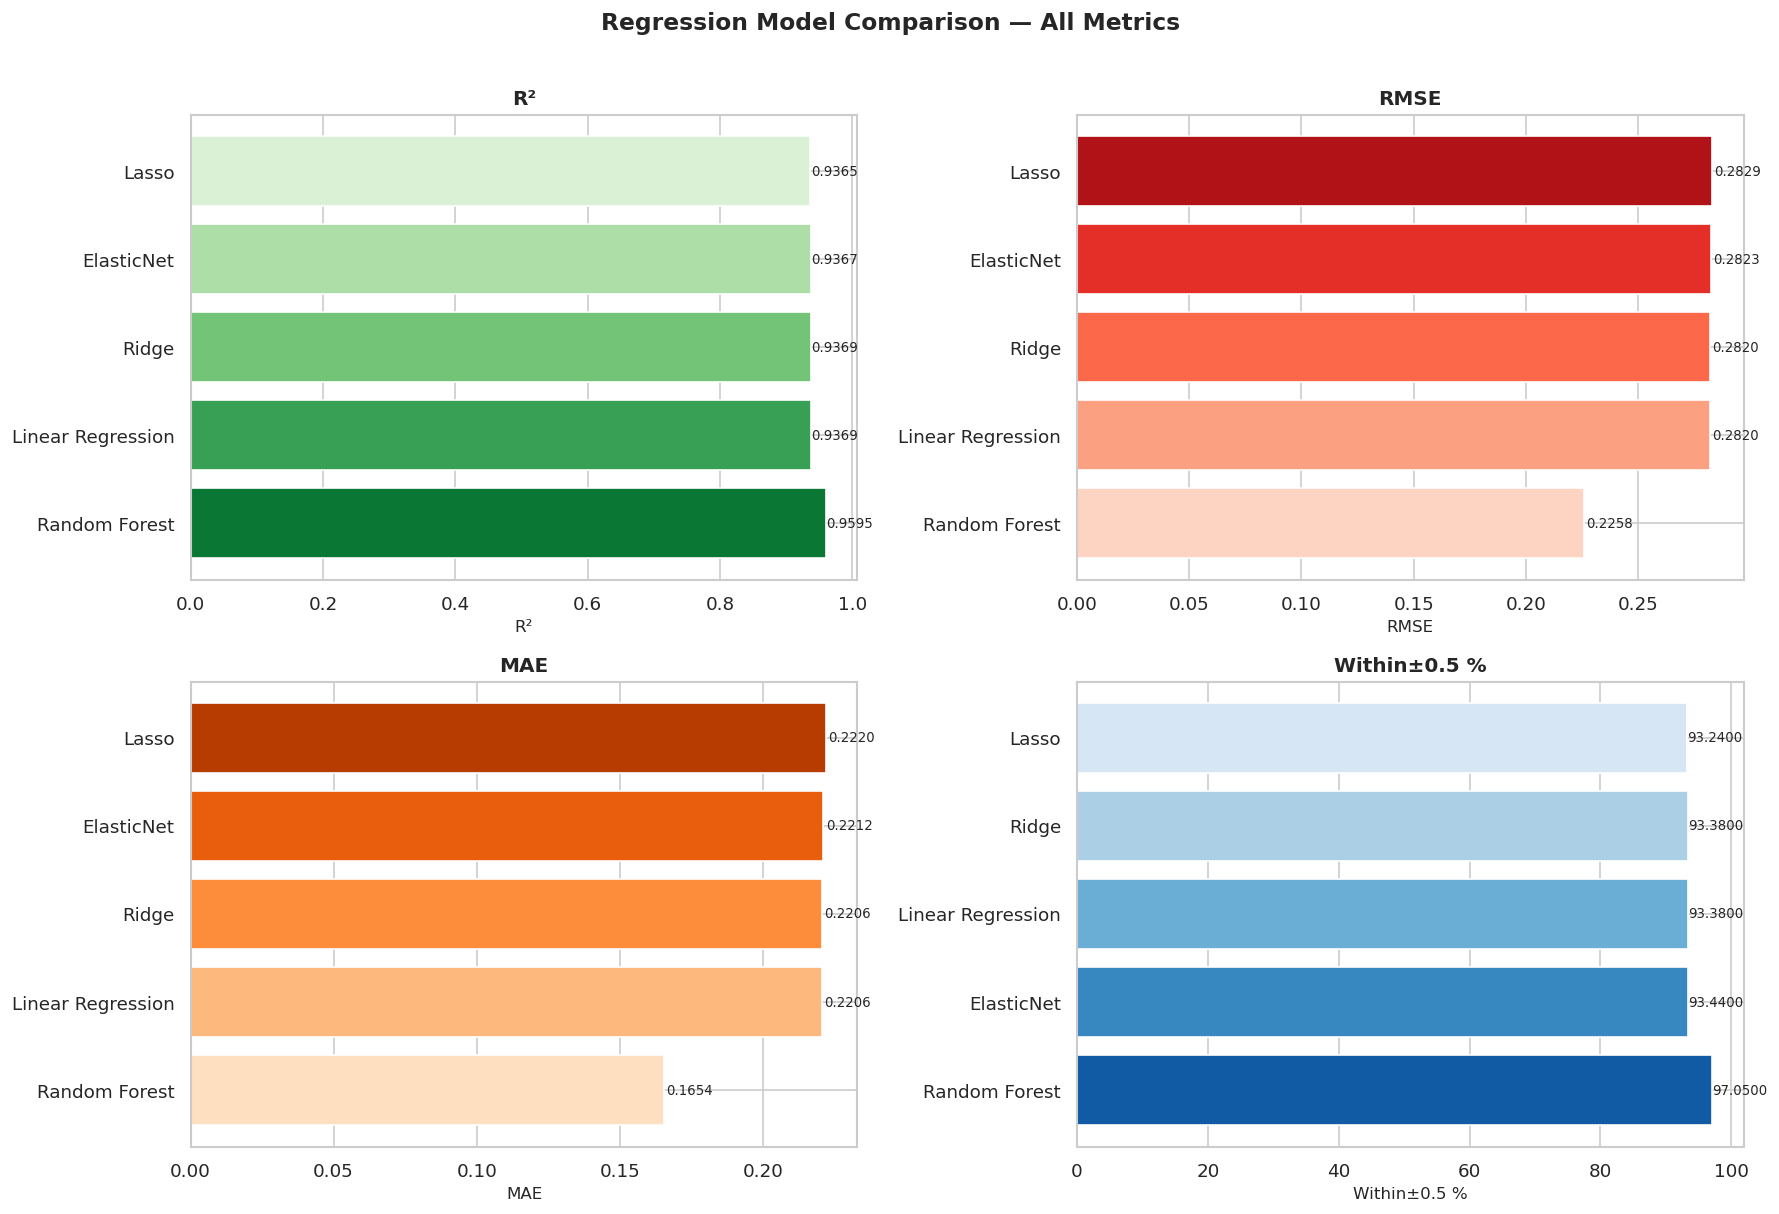

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_cfg = [
    ('R²',            'Greens', False, axes[0,0]),
    ('RMSE',          'Reds',   True,  axes[0,1]),
    ('MAE',           'Oranges',True,  axes[1,0]),
    ('Within±0.5 %',  'Blues',  False, axes[1,1])
]

for metric, cmap_name, ascending, ax in metrics_cfg:
    data   = results_df[metric].sort_values(ascending=ascending)
    colors = sns.color_palette(cmap_name, len(data))
    if not ascending: colors = list(reversed(colors))
    bars = ax.barh(data.index, data.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Regression Model Comparison — All Metrics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

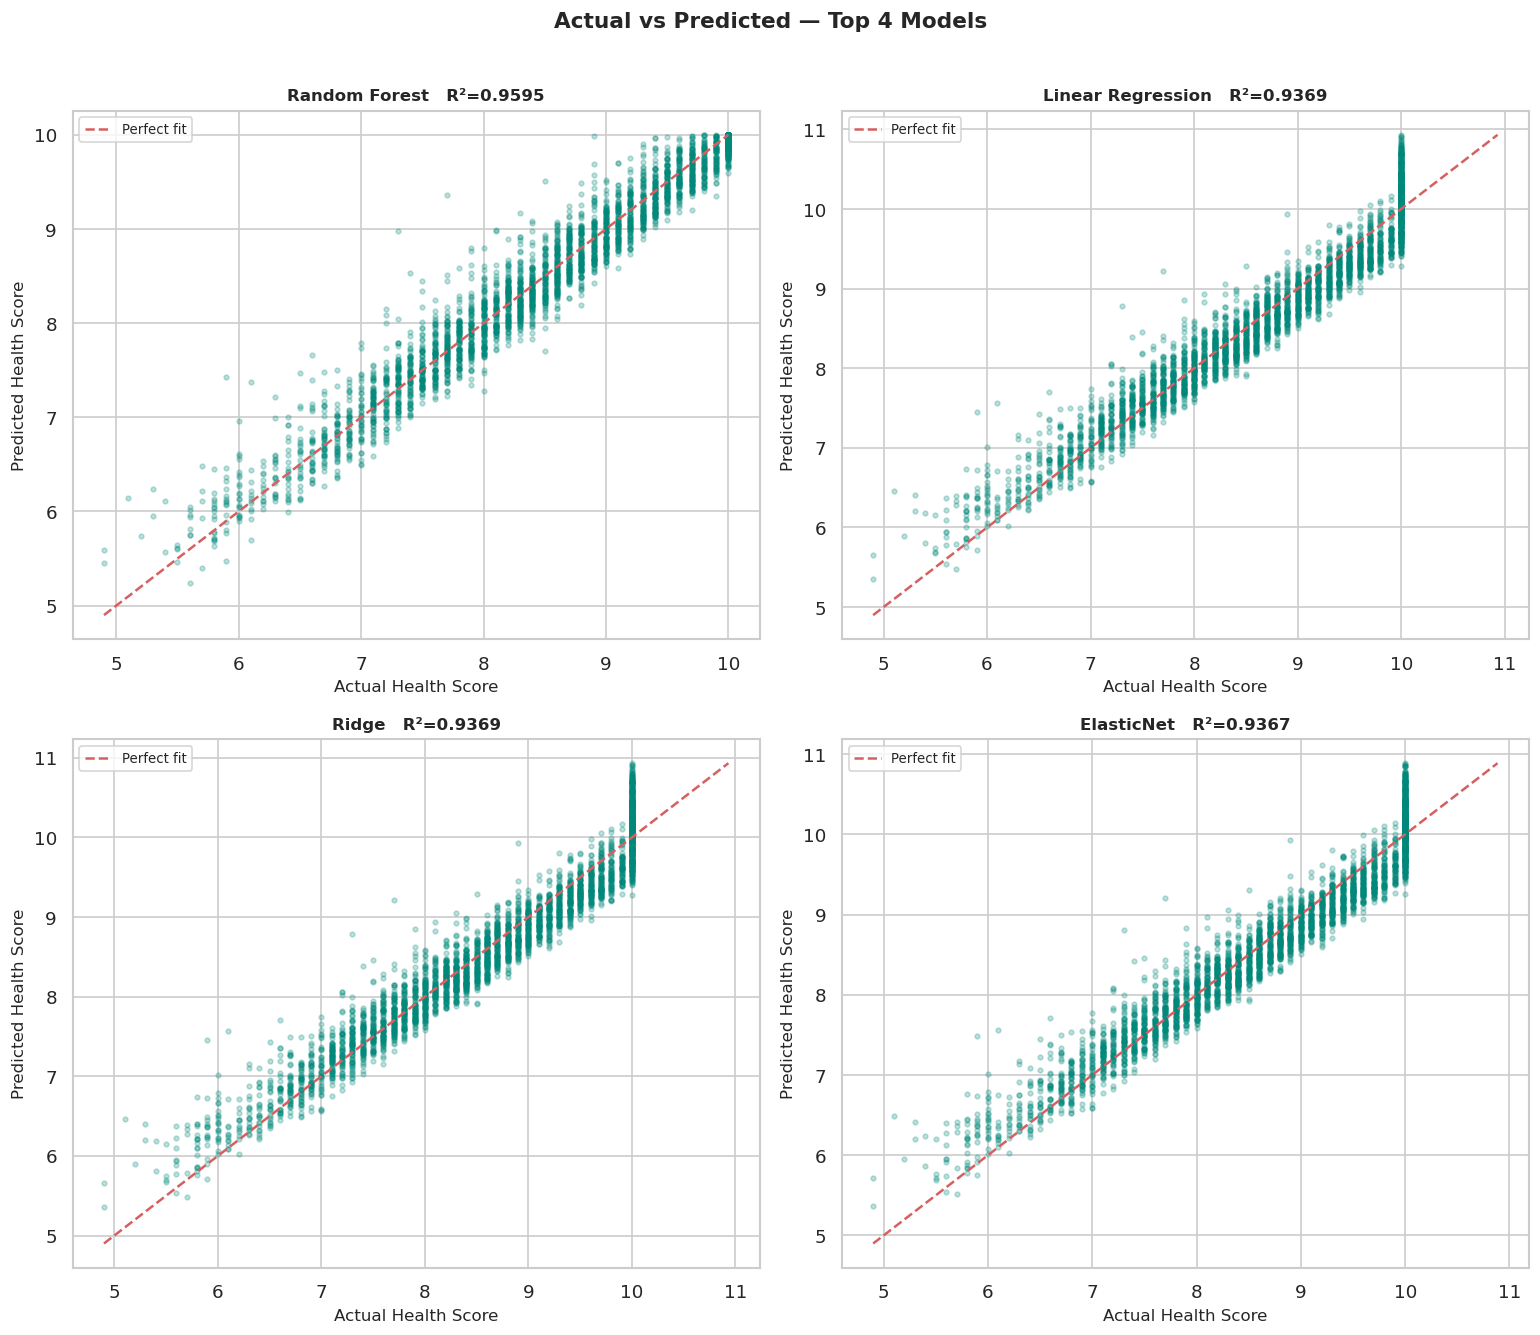

In [59]:
top4 = results_df['R²'].nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, name in zip(axes, top4):
    y_pred = trained_models[name].predict(X_test_sc)
    r2     = r2_score(y_test, y_pred)
    ax.scatter(y_test, y_pred, alpha=0.25, s=8, color='#00897B')
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi],[lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{name}   R²={r2:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual Health Score')
    ax.set_ylabel('Predicted Health Score')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Top 4 Models',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

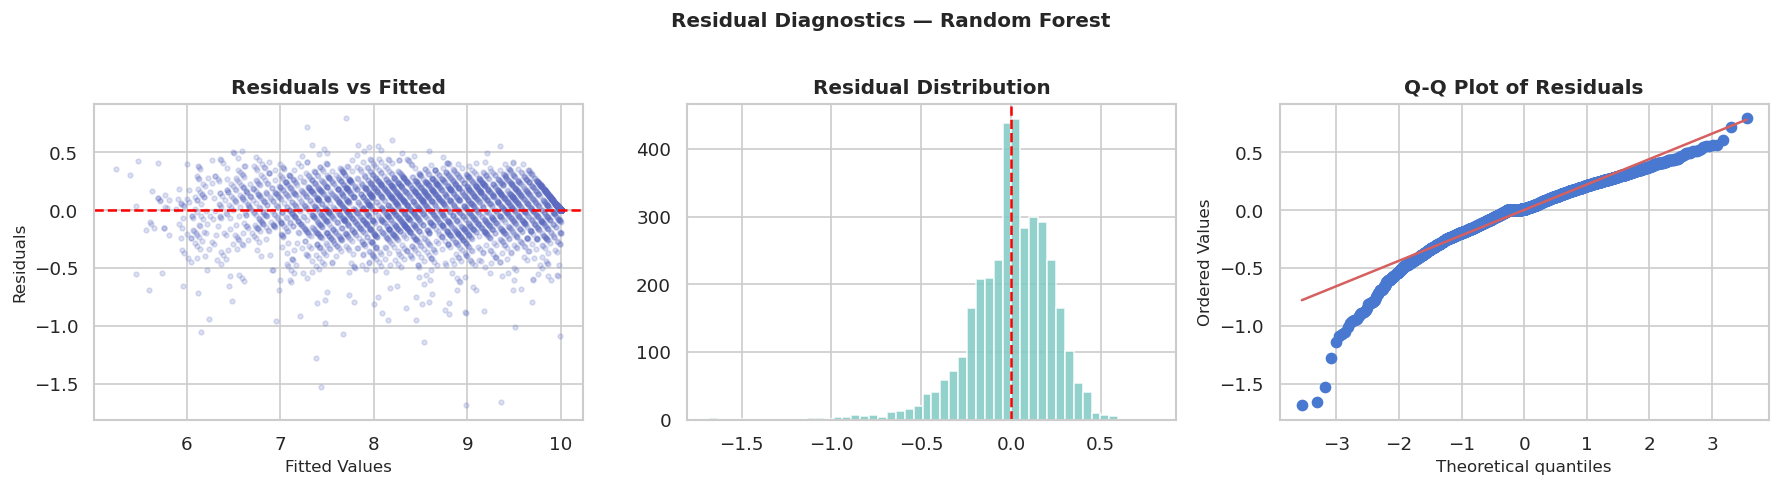

Best baseline model : Random Forest
Residual mean       : 0.00392  (should be ≈ 0)
Residual std        : 0.22577


In [60]:
best_name   = results_df['R²'].idxmax()
best_base   = trained_models[best_name]
y_pred_best = best_base.predict(X_test_sc)
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_best, residuals, alpha=0.2, s=8, color='#5C6BC0')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

axes[1].hist(residuals, bins=50, color='#80CBC4', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.suptitle(f'Residual Diagnostics — {best_name}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f'Best baseline model : {best_name}')
print(f'Residual mean       : {residuals.mean():.5f}  (should be ≈ 0)')
print(f'Residual std        : {residuals.std():.5f}')

## 7. 🎯 Evaluation Metrics, Cross-Validation & Hyperparameter Tuning

In [61]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_records = {}
print('=== 5-Fold CV  (R²) ===')
for name, mdl in MODELS.items():
    scores = cross_val_score(mdl, X_train_sc, y_train, cv=kf,
                              scoring='r2', n_jobs=-1)
    cv_records[name] = scores
    print(f'  {name:22s} → mean: {scores.mean():.4f}  ±{scores.std():.4f}  '
          f'min: {scores.min():.4f}  max: {scores.max():.4f}')

=== 5-Fold CV  (R²) ===
  Linear Regression      → mean: 0.9376  ±0.0019  min: 0.9352  max: 0.9410
  Ridge                  → mean: 0.9376  ±0.0019  min: 0.9352  max: 0.9410
  Lasso                  → mean: 0.9369  ±0.0018  min: 0.9346  max: 0.9399
  ElasticNet             → mean: 0.9373  ±0.0019  min: 0.9350  max: 0.9406
  Random Forest          → mean: 0.9598  ±0.0013  min: 0.9581  max: 0.9620


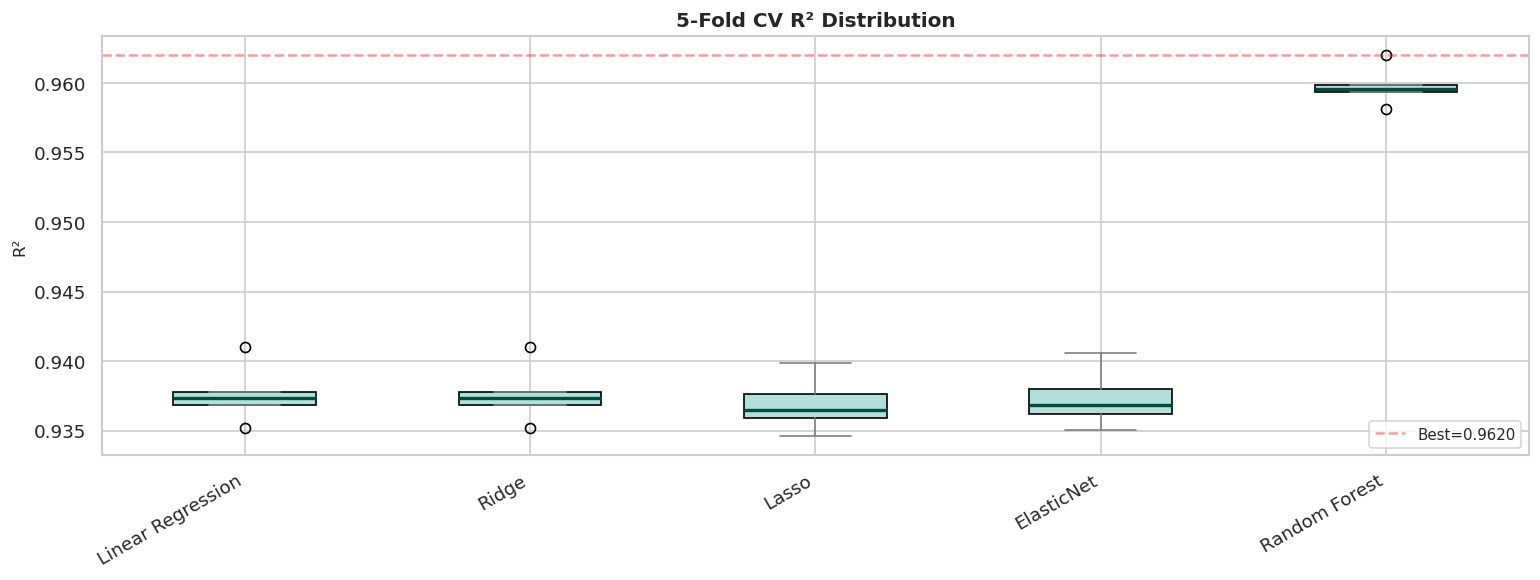

In [62]:
cv_df = pd.DataFrame(cv_records)

fig, ax = plt.subplots(figsize=(13, 5))
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops    =dict(facecolor='#B2DFDB'),
              medianprops =dict(color='#004D40', lw=2),
              whiskerprops=dict(color='gray'),
              capprops    =dict(color='gray'))
ax.set_xticklabels(cv_df.columns, rotation=30, ha='right')
ax.set_title('5-Fold CV R² Distribution', fontweight='bold')
ax.set_ylabel('R²')
ax.axhline(cv_df.values.max(), color='red', ls='--', alpha=0.4,
           label=f'Best={cv_df.values.max():.4f}')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [63]:
from sklearn.ensemble import RandomForestRegressor
rf_base = RandomForestRegressor(random_state=42)

In [64]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [65]:
from sklearn.model_selection import RandomizedSearchCV

rand_cv = RandomizedSearchCV(
    rf_base,
    param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

rand_cv.fit(X_train_sc, y_train)

print(f"\nBest CV R²  : {rand_cv.best_score_:.4f}")
print("Best Params:", rand_cv.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV R²  : 0.9539
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [66]:
# Get best tuned Random Forest model
tuned_rf = rand_cv.best_estimator_

# Predictions
y_pred_tuned = tuned_rf.predict(X_test_sc)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

mse_t  = mean_squared_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mse_t)
mae_t  = mean_absolute_error(y_test, y_pred_tuned)
r2_t   = r2_score(y_test, y_pred_tuned)
mape_t = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100

# Custom metric
within_half = np.mean(np.abs(y_test - y_pred_tuned) <= 0.5) * 100

# Baseline model (mean prediction)
baseline = np.full(len(y_test), y_train.mean())
r2_base  = r2_score(y_test, baseline)

# Output
print('======================================================')
print(' TUNED RANDOM FOREST — TEST SET PERFORMANCE')
print('======================================================')
print(f'  MAE            : {mae_t:.4f}  (avg prediction error)')
print(f'  MSE            : {mse_t:.4f}')
print(f'  RMSE           : {rmse_t:.4f}')
print(f'  MAPE           : {mape_t:.2f}%')
print(f'  R²             : {r2_t:.4f}   (baseline R²={r2_base:.4f})')
print(f'  Within ±0.5    : {within_half:.1f}% of predictions')
print('======================================================')

 TUNED RANDOM FOREST — TEST SET PERFORMANCE
  MAE            : 0.1778  (avg prediction error)
  MSE            : 0.0568
  RMSE           : 0.2382
  MAPE           : 2.20%
  R²             : 0.9549   (baseline R²=-0.0003)
  Within ±0.5    : 96.3% of predictions


In [67]:
import pickle

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(tuned_rf, f)

print("Model saved as random_forest_model.pkl")

Model saved as random_forest_model.pkl



📊 Standardizing features...

🔬 Applying PCA to reduce 27 features to 3 principal components...

✅ PCA transformation complete!
New dataset shape: (17976, 4)

First few rows of transformed data:
        PC1       PC2       PC3  overall_health_score
0 -2.867161  1.965828 -2.101712                   6.5
1  1.369923 -0.868519 -1.954485                   9.4
2 -4.045173 -2.020702 -1.599528                   6.7
3  1.423579  1.432781  0.216535                   9.0
4  2.256400 -0.272119  0.393287                   9.3

📈 Explained Variance by Each Principal Component:
  PC1: 0.2196 (21.96%)
  PC2: 0.1074 (10.74%)
  PC3: 0.1023 (10.23%)

🎯 Total Variance Explained by 3 PCs: 0.4293 (42.93%)

💾 Saved transformed dataset to: dataset_pca_reduced.csv
💾 Saved scaler and PCA model for future transformations
📊 Saved variance analysis plot: pca_variance_analysis.png
📊 Saved feature loadings heatmap: pca_feature_loadings.png

🔍 Top 5 Contributing Features for Each Principal Component:

  PC1:
    - we

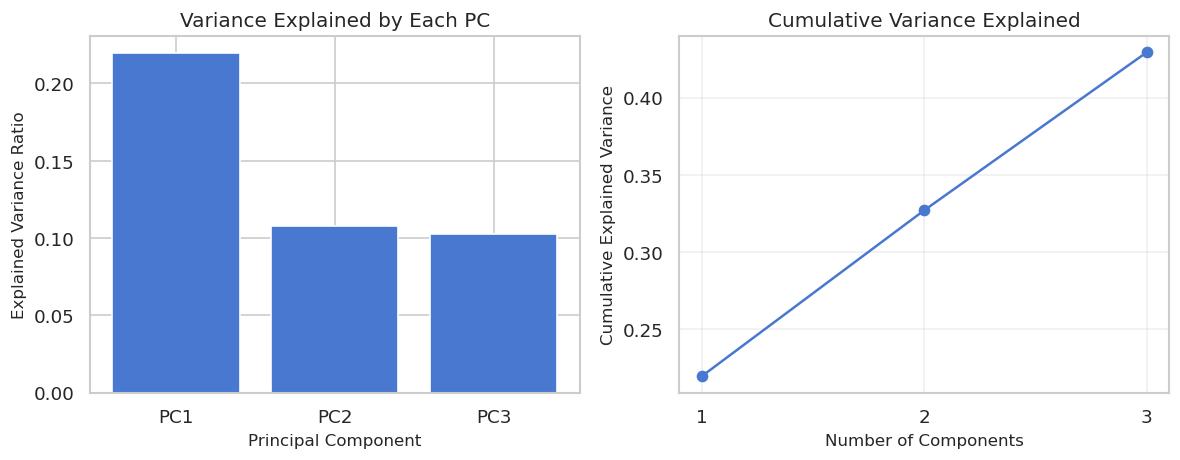

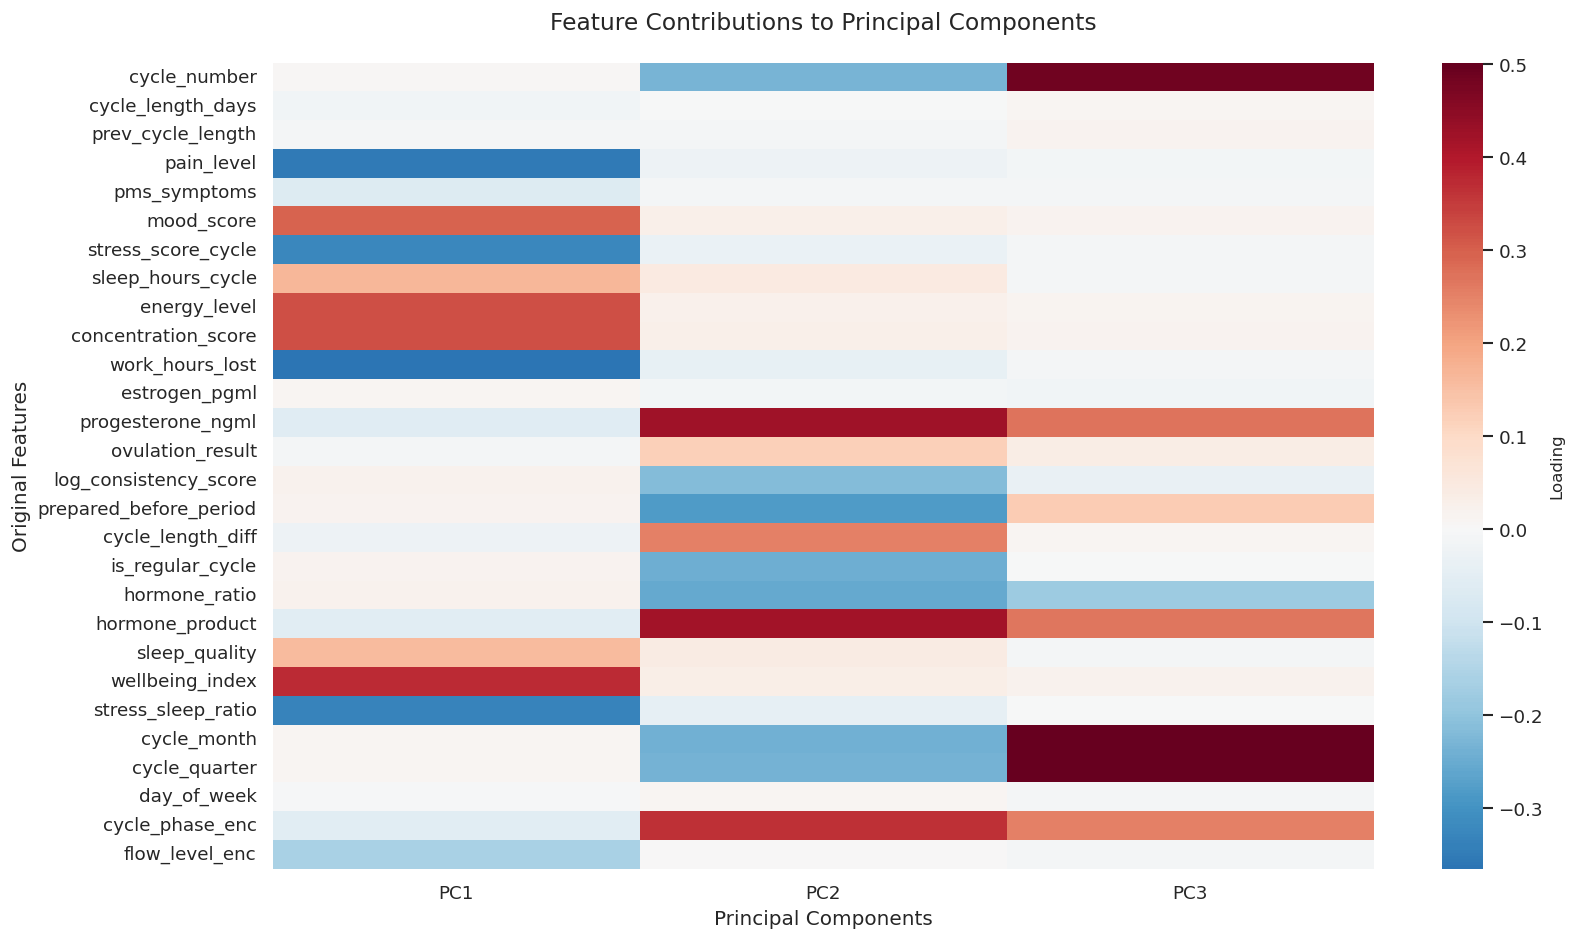

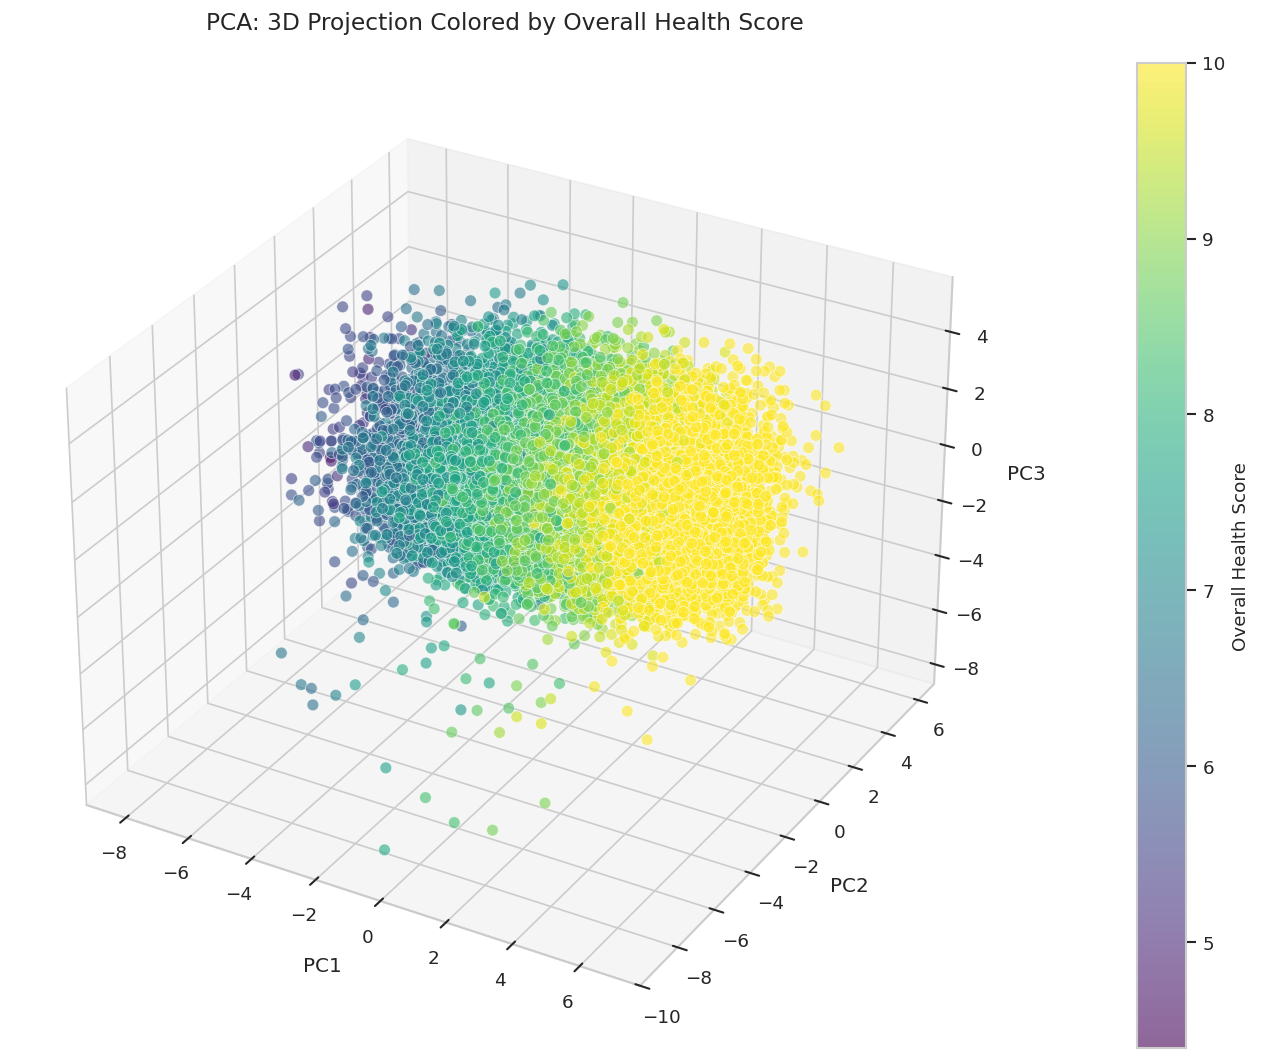

In [80]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['pms_symptoms'] = le.fit_transform(X['pms_symptoms'])
X['ovulation_result'] = le.fit_transform(X['ovulation_result'])
print("\n📊 Standardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
# Apply PCA to reduce to 3 components
print("\n🔬 Applying PCA to reduce 27 features to 3 principal components...")
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
 
# Create a new dataframe with PCA components
df_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2', 'PC3'],
    index=df.index
)
 
# Add the target variable back
df_pca['overall_health_score'] = y.values
 
print("\n✅ PCA transformation complete!")
print(f"New dataset shape: {df_pca.shape}")
print("\nFirst few rows of transformed data:")
print(df_pca.head())
 
# Explained variance ratio
print("\n📈 Explained Variance by Each Principal Component:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")
 
print(f"\n🎯 Total Variance Explained by 3 PCs: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
 
# Save the transformed dataset
output_file = 'dataset_pca_reduced.csv'
df_pca.to_csv(output_file, index=False)
print(f"\n💾 Saved transformed dataset to: {output_file}")
 
# Save the scaler and PCA model for future use
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca_model.pkl')
print("💾 Saved scaler and PCA model for future transformations")
 
# Visualization 1: Explained Variance
plt.figure(figsize=(10, 4))
 
plt.subplot(1, 2, 1)
plt.bar(range(1, 4), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each PC')
plt.xticks(range(1, 4), ['PC1', 'PC2', 'PC3'])
 
plt.subplot(1, 2, 2)
plt.plot(range(1, 4), np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 4))
 
plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=300, bbox_inches='tight')
print("📊 Saved variance analysis plot: pca_variance_analysis.png")
 
# Visualization 2: Feature Contributions to PCs
plt.figure(figsize=(14, 8))
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=FEATURE_NAMES
)
 
# Plot heatmap
sns.heatmap(components_df, cmap='RdBu_r', center=0, 
            annot=False, fmt='.2f', cbar_kws={'label': 'Loading'})
plt.title('Feature Contributions to Principal Components', fontsize=14, pad=20)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Original Features', fontsize=12)
plt.tight_layout()
plt.savefig('pca_feature_loadings.png', dpi=300, bbox_inches='tight')
print("📊 Saved feature loadings heatmap: pca_feature_loadings.png")
 
# Show top contributing features for each PC
print("\n🔍 Top 5 Contributing Features for Each Principal Component:")
for i in range(3):
    print(f"\n  PC{i+1}:")
    loadings = pd.DataFrame({
        'feature': FEATURE_NAMES,
        'loading': np.abs(pca.components_[i])
    }).sort_values('loading', ascending=False)
    
    for idx, row in loadings.head(5).iterrows():
        print(f"    - {row['feature']}: {row['loading']:.4f}")
 
# Visualization 3: 3D scatter plot of PCA components colored by target
from mpl_toolkits.mplot3d import Axes3D
 
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
 
scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], 
                     c=df_pca[TARGET], cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
 
ax.set_xlabel('PC1', fontsize=12, labelpad=10)
ax.set_ylabel('PC2', fontsize=12, labelpad=10)
ax.set_zlabel('PC3', fontsize=12, labelpad=10)
ax.set_title('PCA: 3D Projection Colored by Overall Health Score', fontsize=14, pad=20)
 
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Overall Health Score', fontsize=11)
 
plt.tight_layout()
plt.savefig('pca_3d_visualization.png', dpi=300, bbox_inches='tight')
print("📊 Saved 3D PCA visualization: pca_3d_visualization.png")
 
print("\n" + "="*60)
print("✨ PCA REDUCTION COMPLETE!")
print("="*60)
print(f"Original dimensions: {X.shape[1]} features")
print(f"Reduced dimensions: 3 principal components")
print(f"Information retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("="*60)
 

In [81]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Train model on PCA data
model = RandomForestRegressor()
model.fit(X_pca, y)

RandomForestRegressor()

In [85]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3)),
    ('model', RandomForestRegressor())
])

pipeline.fit(X, y)

# Save FULL pipeline (IMPORTANT)
pickle.dump(pipeline, open('model.pkl', 'wb'))